## Week 5 | AnalystLab Africa | Building Baseline Model ( Finally !!!!)

## import all the essential libraries

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os # Import os module
warnings.filterwarnings('ignore')

# # Import the Data

In [29]:
df = pd.read_csv('/content/HealthConnect_Appointment_Data.csv')

## display the top 10 rows

In [30]:
df.head(10)

,appointment_id,patient_id,gender,age,age_group,appointment_type,booking_date,appointment_date,appointment_day,appointment_time,booking_lead_days,previous_appointments,previous_no_shows,reminder_sent,reminder_channel,distance_to_clinic_km,waiting_time_minutes,appointment_outcome
0,HC-00001,P-1613,Female,39,35-44,Follow-up,2/6/2025,2/18/2025,Tuesday,Afternoon,12,2,0,Yes,WhatsApp,19.3,29.0,No-Show
1,HC-00002,P-0813,Male,31,25-34,Specialist Consultation,2/25/2026,2/27/2026,Friday,Morning,2,6,0,Yes,SMS,14.3,42.0,Attended
2,HC-00003,P-1366,Female,50,45-54,General Consultation,11/16/2025,12/24/2025,Wednesday,Morning,38,5,1,Yes,SMS,11.4,11.0,No-Show
3,HC-00004,P-1031,Male,59,55-64,Follow-up,7/18/2025,8/28/2025,Thursday,Evening,41,3,1,Yes,SMS,7.4,35.0,Attended
4,HC-00005,P-1458,Female,34,25-34,Follow-up,7/9/2025,8/25/2025,Monday,Afternoon,47,3,1,Yes,Email,5.6,27.0,No-Show
5,HC-00006,P-0523,Male,66,65+,Specialist Consultation,2/16/2026,4/14/2026,Tuesday,Morning,57,4,2,No,NaN,3.1,36.0,No-Show
6,HC-00007,P-0776,Male,58,55-64,Diagnostic Test,1/17/2025,2/16/2025,Sunday,Afternoon,30,4,1,Yes,WhatsApp,8.2,30.0,No-Show
7,HC-00008,P-0927,Female,28,25-34,Specialist Consultation,11/27/2025,1/16/2026,Friday,Afternoon,50,6,1,Yes,SMS,19.2,21.0,Attended
8,HC-00009,P-0388,Male,77,65+,Follow-up,3/9/2025,4/21/2025,Monday,Afternoon,43,3,0,Yes,SMS,10.1,27.0,No-Show
9,HC-00010,P-0371,Female,20,18-24,Follow-up,2/5/2025,2/21/2025,Friday,Afternoon,16,2,0,Yes,SMS,28.0,20.0,Attended


In [31]:
df.shape

(5000, 18)

## EDA

In [32]:
df.describe()

,age,booking_lead_days,previous_appointments,previous_no_shows,distance_to_clinic_km,waiting_time_minutes
count,5000.000000,5000.00000,5000.000000,5000.000000,4910.000000,4940.000000
mean,48.794800,29.63860,3.013800,0.544200,10.109572,24.189676
std,18.138547,17.39936,1.741211,0.746832,6.590030,10.863184
min,18.000000,0.00000,0.000000,0.000000,0.500000,2.000000
25%,33.000000,15.00000,2.000000,0.000000,5.300000,17.000000
50%,49.000000,30.00000,3.000000,0.000000,8.700000,24.000000
75%,64.000000,45.00000,4.000000,1.000000,13.500000,32.000000
max,80.000000,60.00000,11.000000,5.000000,45.000000,68.000000


In [33]:
df.describe(include='object')

,appointment_id,patient_id,gender,age_group,appointment_type,booking_date,appointment_date,appointment_day,appointment_time,reminder_sent,reminder_channel,appointment_outcome
count,5000,5000,5000,5000,5000,5000,5000,5000,5000,5000,3634,5000
unique,5000,1696,3,6,4,593,545,7,3,2,3,3
top,HC-05000,P-1742,Female,65+,General Consultation,8/24/2025,3/14/2026,Wednesday,Morning,Yes,SMS,No-Show
freq,1,9,2488,1241,2086,20,18,737,2227,3634,2000,2423


In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   appointment_id         5000 non-null   object 
 1   patient_id             5000 non-null   object 
 2   gender                 5000 non-null   object 
 3   age                    5000 non-null   int64  
 4   age_group              5000 non-null   object 
 5   appointment_type       5000 non-null   object 
 6   booking_date           5000 non-null   object 
 7   appointment_date       5000 non-null   object 
 8   appointment_day        5000 non-null   object 
 9   appointment_time       5000 non-null   object 
 10  booking_lead_days      5000 non-null   int64  
 11  previous_appointments  5000 non-null   int64  
 12  previous_no_shows      5000 non-null   int64  
 13  reminder_sent          5000 non-null   object 
 14  reminder_channel       3634 non-null   object 
 15  dist

In [35]:
# check for missing values
df.isnull().sum()

,0
appointment_id,0
patient_id,0
gender,0
age,0
age_group,0
appointment_type,0
booking_date,0
appointment_date,0
appointment_day,0
appointment_time,0


In [36]:
df[df['reminder_channel'].isnull()]['reminder_sent'].value_counts()

,count
reminder_sent,
No,1366


# so basically whenver the reminder sent is `NO` , the reminder channel is `null` (*that make sense indeed*)


In [37]:
# Fill null values in 'reminder_channel'
df['reminder_channel'].fillna(value='No_Reminder_Channel', inplace=True)

# Check for missing values again to confirm
print("Null counts after correctly filling 'reminder_channel':")
df.isnull().sum()

Null counts after correctly filling 'reminder_channel':


,0
appointment_id,0
patient_id,0
gender,0
age,0
age_group,0
appointment_type,0
booking_date,0
appointment_date,0
appointment_day,0
appointment_time,0


### Rationale for handling `reminder_channel` missing values

The `reminder_channel` column had missing values (NaN) only when the `reminder_sent` column indicated 'No'. This suggests that a missing `reminder_channel` is not an error, but rather a meaningful absence of data: if no reminder was sent, there's no channel to record.

Therefore, instead of dropping these rows (which would mean losing valuable data from patients who did not receive reminders), the nulls were filled with 'No_Reminder_Channel'. This approach preserves the data and makes the absence of a reminder channel explicit and interpretable, allowing us to analyze patterns related to patients who did or did not receive reminders.

In [38]:
# Fill missing values in 'distance_to_clinic_km' with its median
median_distance = df['distance_to_clinic_km'].median()
df['distance_to_clinic_km'].fillna(value=median_distance, inplace=True)

print(f"Filled 'distance_to_clinic_km' nulls with median: {median_distance:.2f}")

Filled 'distance_to_clinic_km' nulls with median: 8.70


In [39]:
# Fill missing values in 'waiting_time_minutes' with its median
median_waiting_time = df['waiting_time_minutes'].median()
df['waiting_time_minutes'].fillna(value=median_waiting_time, inplace=True)

print(f"Filled 'waiting_time_minutes' nulls with median: {median_waiting_time:.2f}")

Filled 'waiting_time_minutes' nulls with median: 24.00


In [40]:
# Check for missing values again to confirm all relevant nulls have been handled
print("Missing values after filling 'distance_to_clinic_km' and 'waiting_time_minutes':")
df.isnull().sum()

Missing values after filling 'distance_to_clinic_km' and 'waiting_time_minutes':


,0
appointment_id,0
patient_id,0
gender,0
age,0
age_group,0
appointment_type,0
booking_date,0
appointment_date,0
appointment_day,0
appointment_time,0


#check for duplicates

In [41]:
df.duplicated().sum()

np.int64(0)

In [42]:
df.dtypes

,0
appointment_id,object
patient_id,object
gender,object
age,int64
age_group,object
appointment_type,object
booking_date,object
appointment_date,object
appointment_day,object
appointment_time,object


##**our main target is prediction of show vs no_show , so we will drop `cancelled`**

In [43]:
df_model = df[df['appointment_outcome']!= 'Cancelled'].copy()

df_model['appointment_outcome'].value_counts()

,count
appointment_outcome,
No-Show,2423
Attended,2314


In [44]:
df_model.shape

(4737, 18)

## Distrubution of the Target

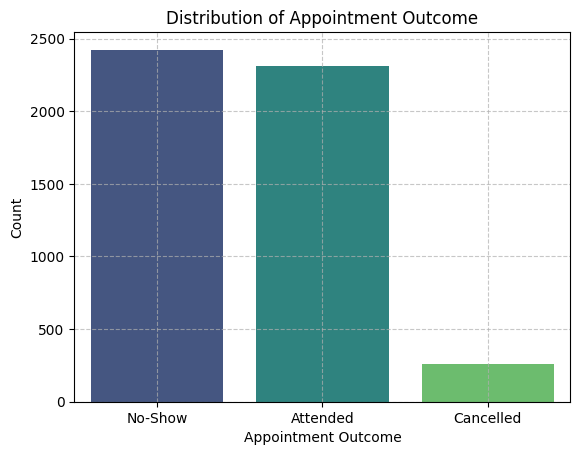

In [64]:
sns.countplot(data=df , x='appointment_outcome', palette='viridis')
plt.title('Distribution of Appointment Outcome')
plt.xlabel('Appointment Outcome')
plt.ylabel('Count')
plt.grid(True, linestyle='--', alpha=0.7 )

output_dir = 'figures'
os.makedirs(output_dir, exist_ok=True)
plt.savefig(os.path.join(output_dir, 'target_distribution.png')) # Save the figure
plt.show()

## Numerical Disturbution

In [46]:
numerical_col= df.select_dtypes(include='number')

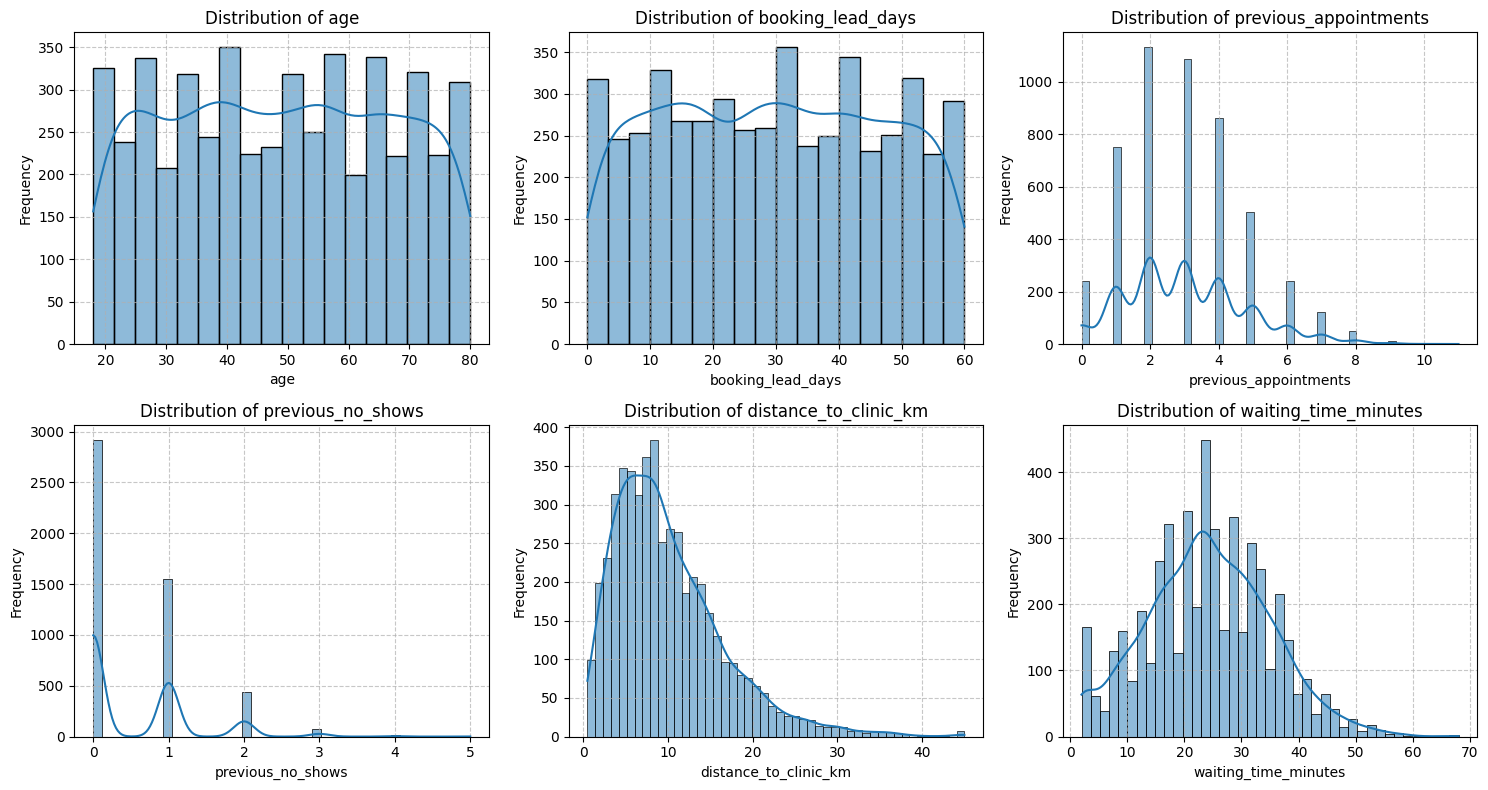

In [47]:
numerical_columns_list = numerical_col.columns.tolist()

# Calculate number of rows and columns for subplots, aiming for 3 columns per row
n_cols = 3
n_rows = (len(numerical_columns_list) + n_cols - 1) // n_cols

plt.figure(figsize=(n_cols * 5, n_rows * 4))

for i, col in enumerate(numerical_columns_list):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.histplot(data=numerical_col, x=col, kde=True, palette='viridis')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()

# Create 'figures' directory if it doesn't exist
output_dir = 'figures'
os.makedirs(output_dir, exist_ok=True)
plt.savefig(os.path.join(output_dir, 'numerical_distributions.png')) # Save the figure
plt.show()

### Visualizing Numerical Columns vs. Appointment Outcome (Box Plots)

Let's visualize the distribution of each numerical feature against the `appointment_outcome` using box plots. This will help us understand if there's a difference in the spread and central tendency of these features between 'No-Show' and 'Attended' appointments.

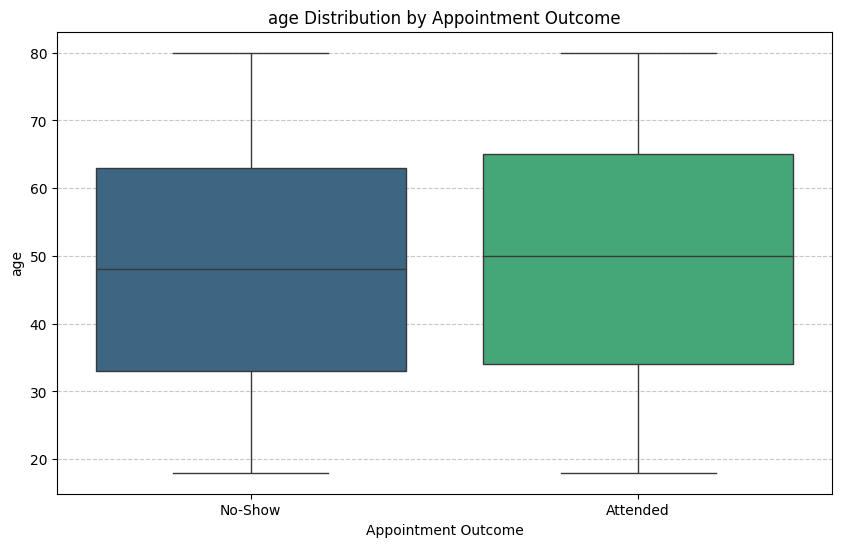

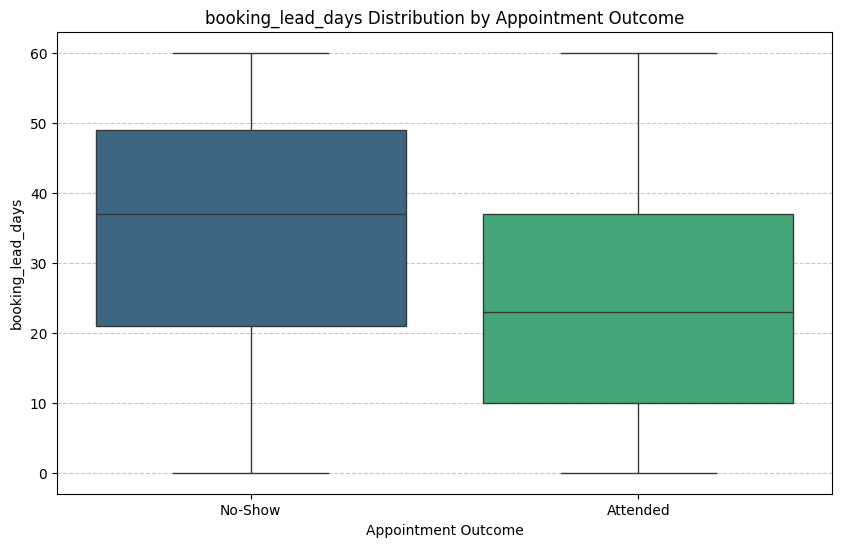

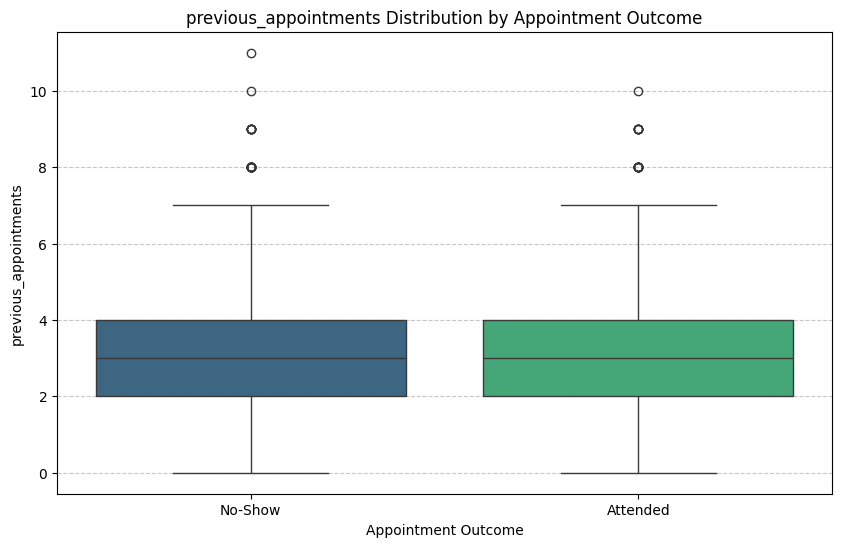

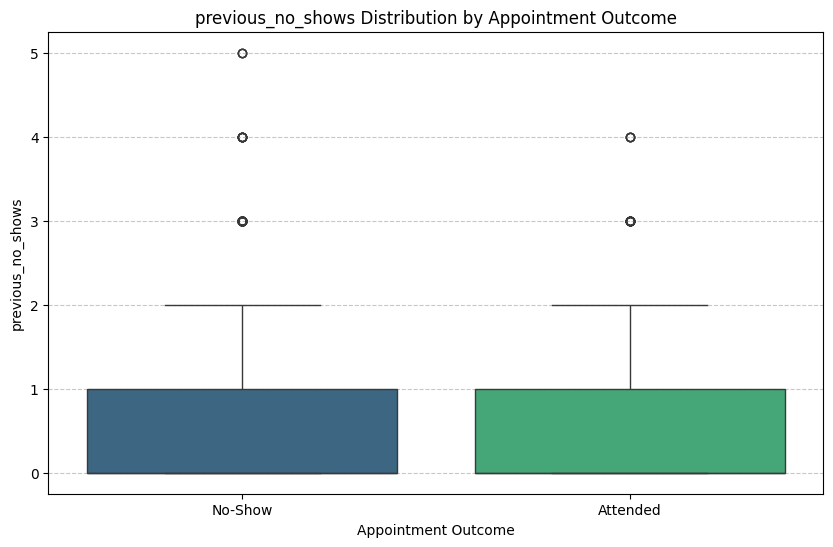

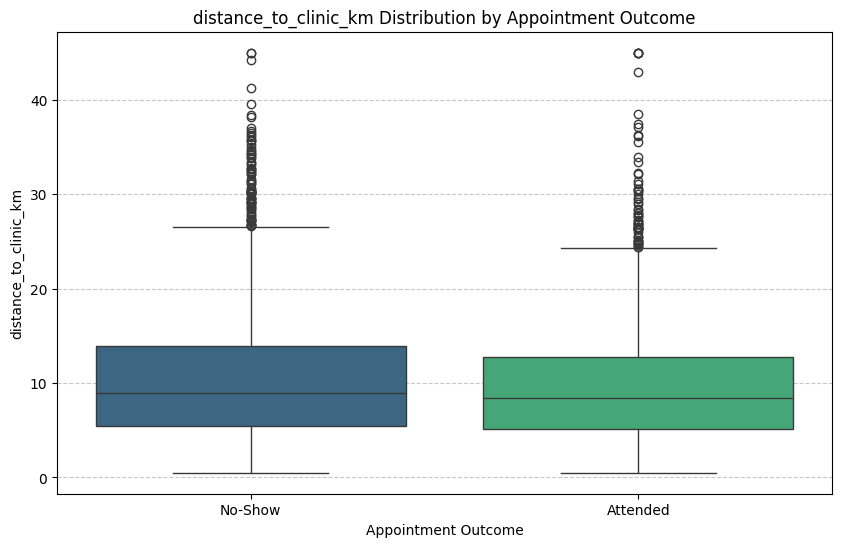

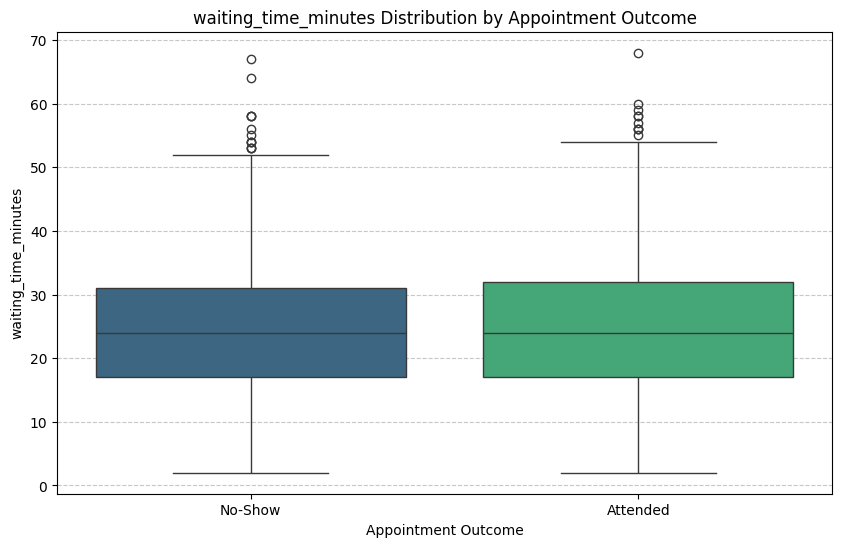

In [48]:
output_dir = 'figures'
os.makedirs(output_dir, exist_ok=True)

for col in numerical_col.columns:
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=df_model, x='appointment_outcome', y=col, palette='viridis')
    plt.title(f'{col} Distribution by Appointment Outcome')
    plt.xlabel('Appointment Outcome')
    plt.ylabel(col)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.savefig(os.path.join(output_dir, f'boxplot_{col}_by_outcome.png')) # Save each box plot
    plt.show()

### Analyzing Categorical Columns vs. Appointment Outcome (Cross-Tabulations)

Now, let's examine the relationship between categorical features and the `appointment_outcome` using cross-tabulations, displaying the results as percentages for easier interpretation.

In [49]:
categorical_cols = df_model.select_dtypes(include='object').columns.tolist()
# Exclude identifier columns that are not useful for this analysis
categorical_cols_to_analyze = [col for col in categorical_cols if col not in ['appointment_id', 'patient_id', 'booking_date', 'appointment_date']]

for col in categorical_cols_to_analyze:
    print(f"\n--- Cross-Tabulation for '{col}' vs. 'appointment_outcome' (Percentages) ---")
    cross_tab = pd.crosstab(df_model[col], df_model['appointment_outcome'], normalize='index') * 100
    display(cross_tab.round(2))


--- Cross-Tabulation for 'gender' vs. 'appointment_outcome' (Percentages) ---


appointment_outcome,Attended,No-Show
gender,,
Female,48.90,51.10
Male,48.50,51.50
Prefer not to say,55.24,44.76



--- Cross-Tabulation for 'age_group' vs. 'appointment_outcome' (Percentages) ---


appointment_outcome,Attended,No-Show
age_group,,
18-24,47.59,52.41
25-34,47.07,52.93
35-44,48.57,51.43
45-54,48.93,51.07
55-64,47.00,53.00
65+,51.93,48.07



--- Cross-Tabulation for 'appointment_type' vs. 'appointment_outcome' (Percentages) ---


...

appointment_outcome,Attended,No-Show
reminder_sent,,
No,45.37,54.63
Yes,50.14,49.86



--- Cross-Tabulation for 'reminder_channel' vs. 'appointment_outcome' (Percentages) ---


appointment_outcome,Attended,No-Show
reminder_channel,,
Email,49.01,50.99
No_Reminder_Channel,45.37,54.63
SMS,52.02,47.98
WhatsApp,47.26,52.74



--- Cross-Tabulation for 'appointment_outcome' vs. 'appointment_outcome' (Percentages) ---


appointment_outcome,Attended,No-Show
appointment_outcome,,
Attended,100.0,0.0
No-Show,0.0,100.0


### Visualizing Categorical Columns vs. Appointment Outcome (Bar Plots)

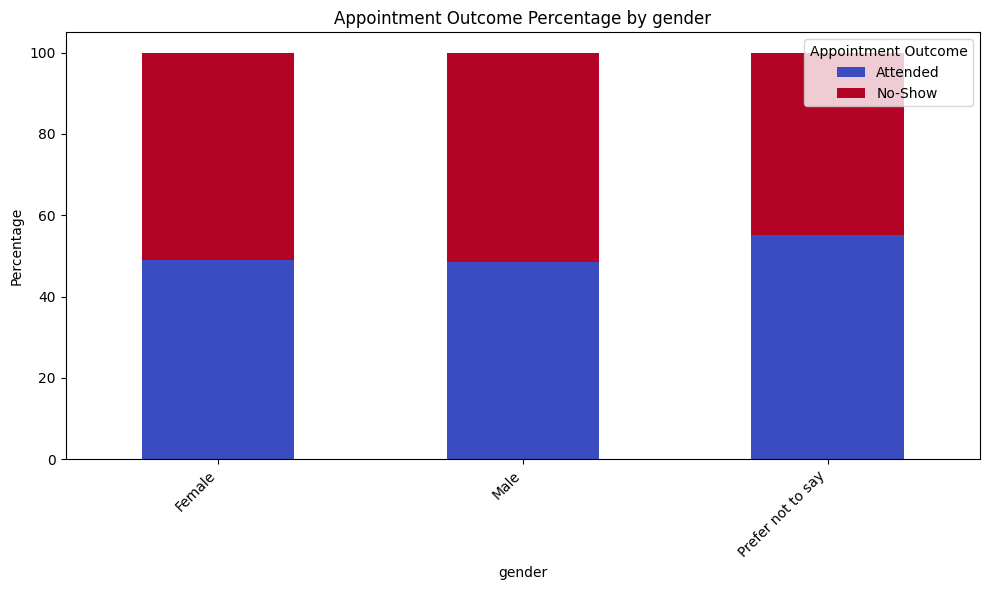

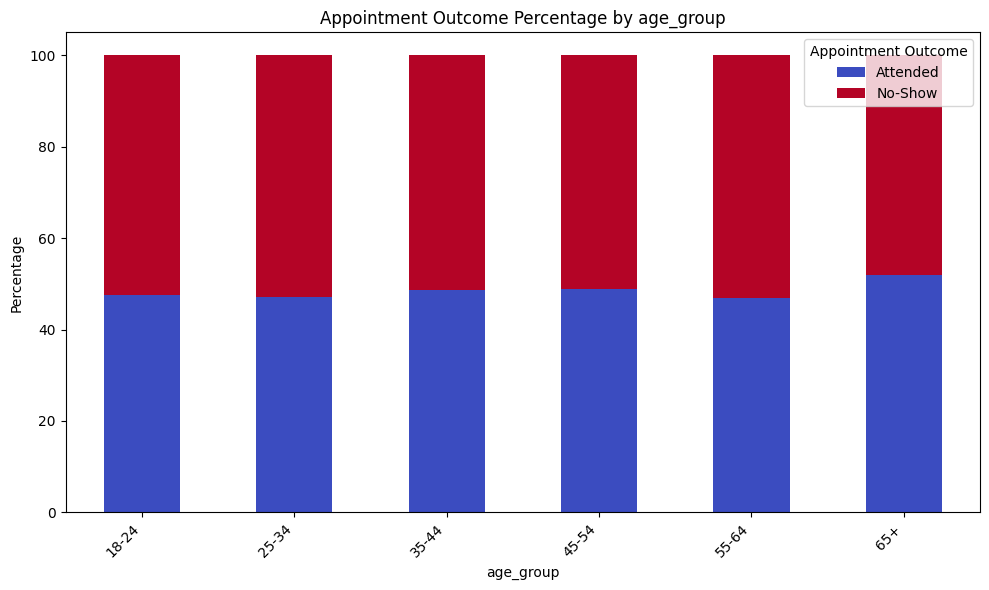

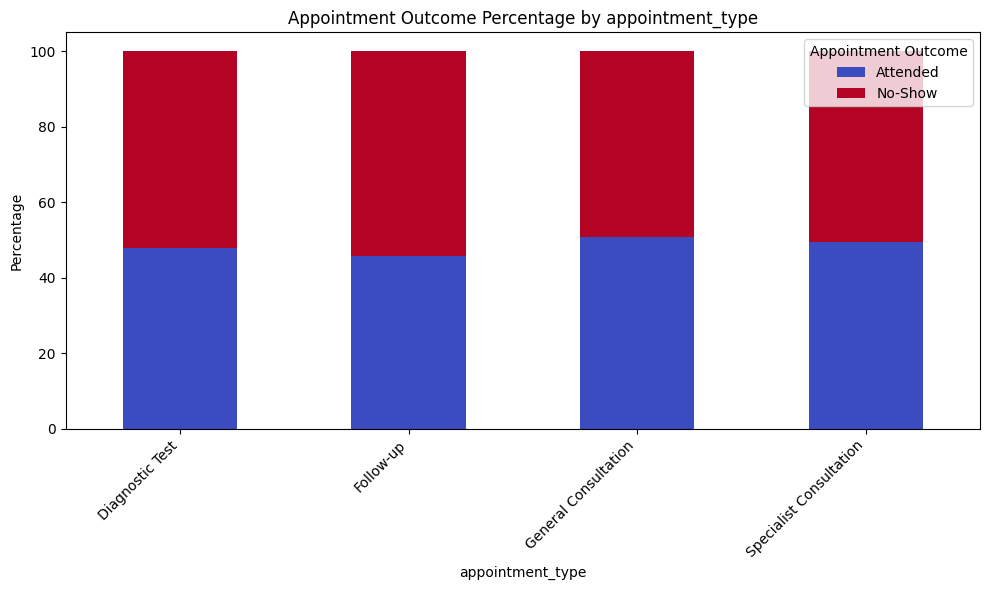

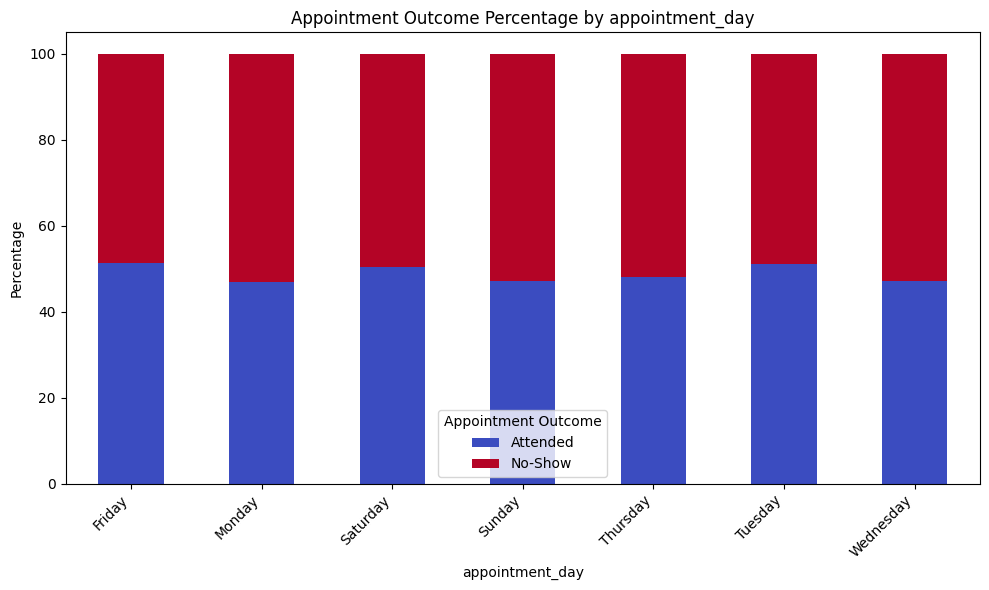

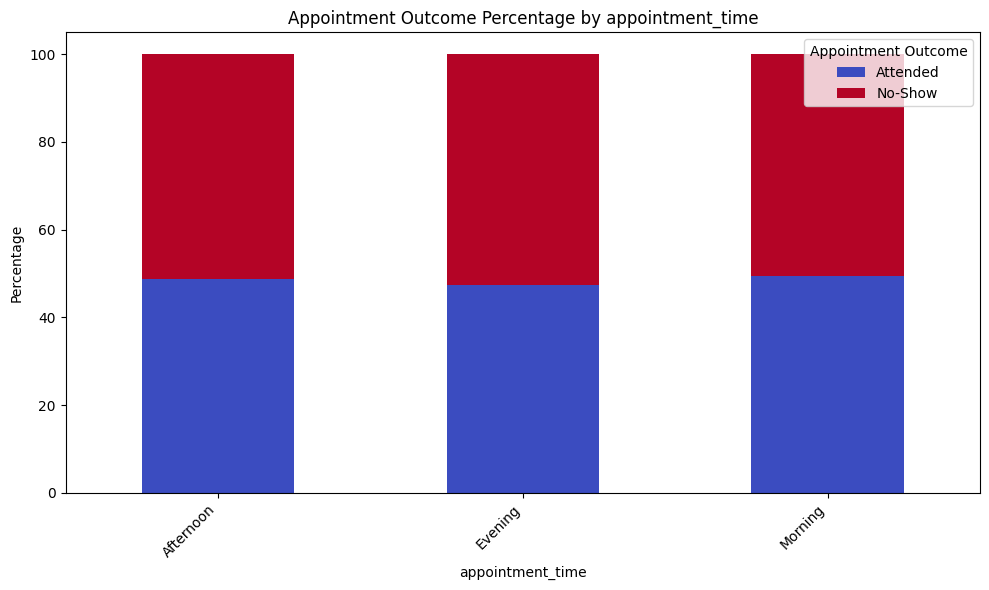

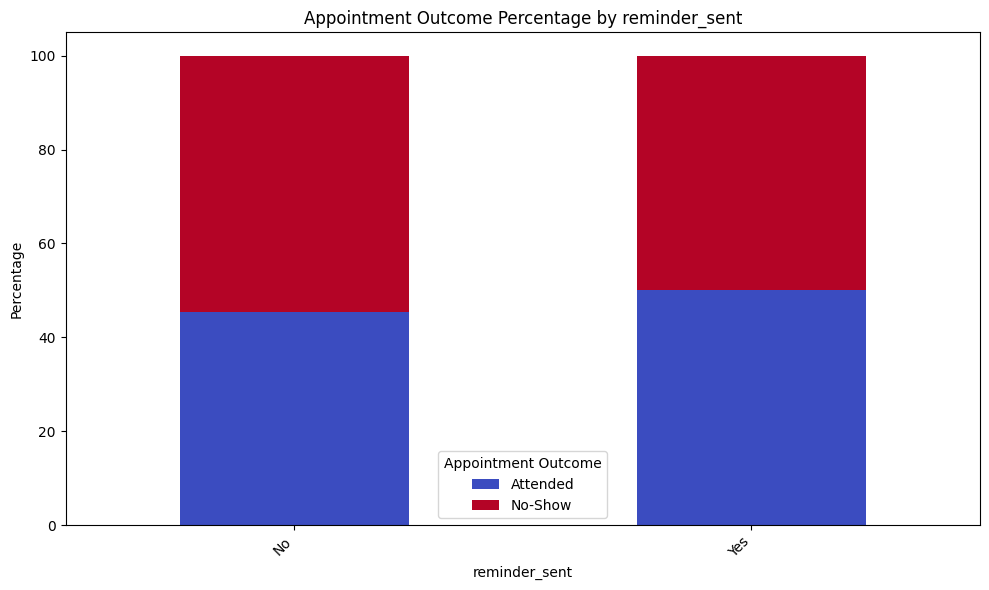

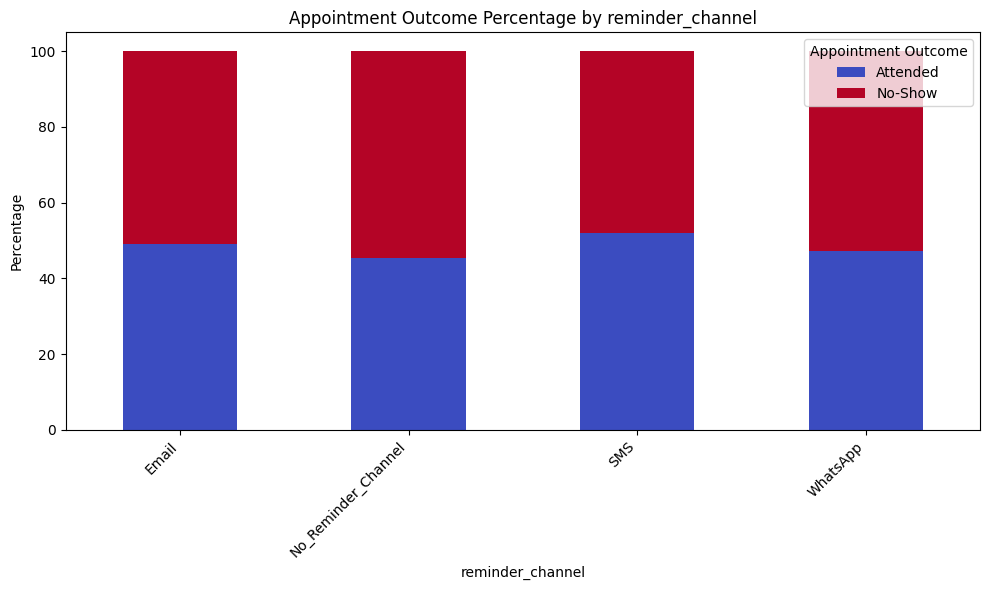

In [50]:
output_dir = 'figures'
os.makedirs(output_dir, exist_ok=True)

for col in categorical_cols_to_analyze:
    if col != 'appointment_outcome': # Exclude the target variable itself
        cross_tab_plot = pd.crosstab(df_model[col], df_model['appointment_outcome'], normalize='index') * 100
        cross_tab_plot.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='coolwarm')
        plt.title(f'Appointment Outcome Percentage by {col}')
        plt.xlabel(col)
        plt.ylabel('Percentage')
        plt.xticks(rotation=45, ha='right')
        plt.legend(title='Appointment Outcome')
        plt.tight_layout()
        plt.savefig(os.path.join(output_dir, f'barplot_{col}_by_outcome.png')) # Save each bar plot
        plt.show()

### Correlation Matrix of Numerical Features

Let's compute and visualize the correlation matrix for the numerical features. This will help us understand the linear relationships between these variables.

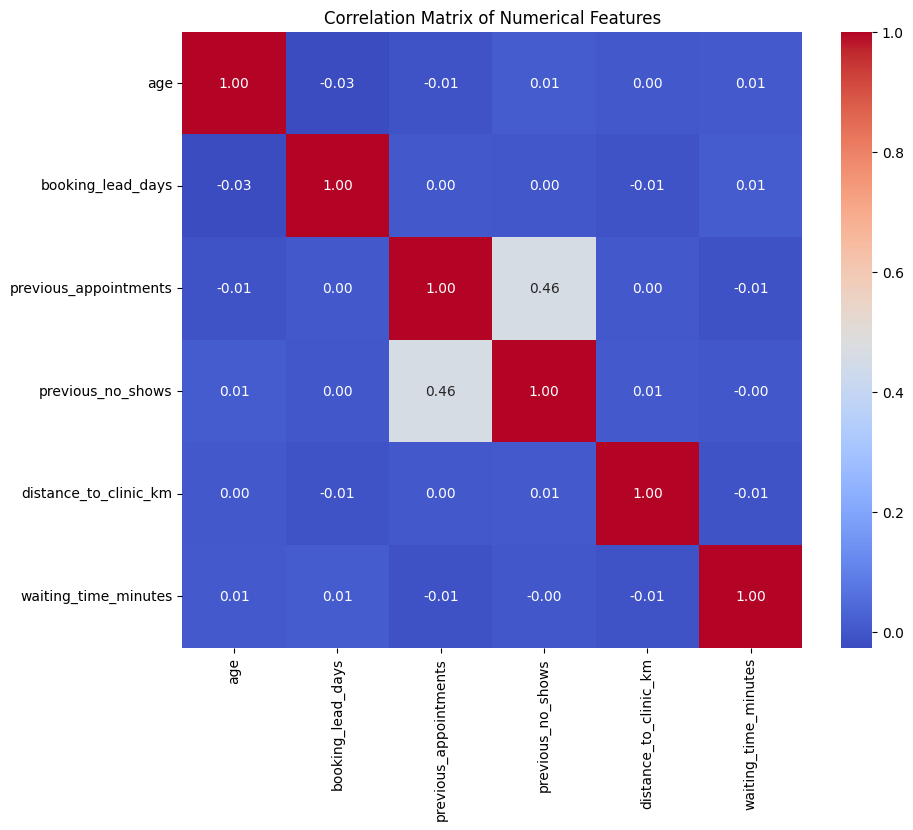

In [51]:
plt.figure(figsize=(10, 8))
sns.heatmap(numerical_col.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Features')

output_dir = 'figures'
os.makedirs(output_dir, exist_ok=True)
plt.savefig(os.path.join(output_dir, 'correlation_matrix_numerical.png')) # Save the figure
plt.show()

### Feature Engineering

Let's create some new features that might be useful for predicting appointment outcomes.

In [52]:
# 1. Create 'previous_no_show_rate'
# Handle potential division by zero: if previous_appointments is 0, rate is 0.
df_model['previous_no_show_rate'] = df_model.apply(lambda row: row['previous_no_shows'] / row['previous_appointments'] if row['previous_appointments'] > 0 else 0, axis=1)

# 2. Create 'has_previous_no_show'
df_model['has_previous_no_show'] = (df_model['previous_no_shows'] > 0).astype(int)

# 3. Extract 'booking_month'
# First, ensure 'booking_date' is in datetime format
df_model['booking_date'] = pd.to_datetime(df_model['booking_date'])
df_model['booking_month'] = df_model['booking_date'].dt.month

print("New features added to df_model:")
display(df_model[['previous_no_show_rate', 'has_previous_no_show', 'booking_month']].head())

New features added to df_model:


,previous_no_show_rate,has_previous_no_show,booking_month
0,0.000000,0,2
1,0.000000,0,2
2,0.200000,1,11
3,0.333333,1,7
4,0.333333,1,7


### Documenting Added Features



*   **`previous_no_show_rate`**: Calculated as `previous_no_shows / previous_appointments`. This feature represents the proportion of previous appointments that resulted in a no-show for a given patient. If a patient had no previous appointments, the rate is set to 0.

*   **`has_previous_no_show`**: A binary (0 or 1) indicator feature. It is 1 if a patient has one or more `previous_no_shows`, and 0 otherwise. This can highlight patients with any history of missing appointments.

*   **`long_booking_lead`**: A binary (0 or 1) indicator feature. It is 1 if the `booking_lead_days` for an appointment is greater than the median `booking_lead_days` across the dataset, and 0 otherwise. This feature aims to capture if longer booking lead times are associated with different outcomes.

*   **`booking_month`**: An integer feature representing the month in which the appointment was booked, extracted from the `booking_date` column. This could help identify seasonality or monthly trends in appointment outcomes.

### Multicollinearity Check for New Features

Let's examine the correlations between the newly engineered features to identify any potential multicollinearity, which can be important for some modeling techniques.

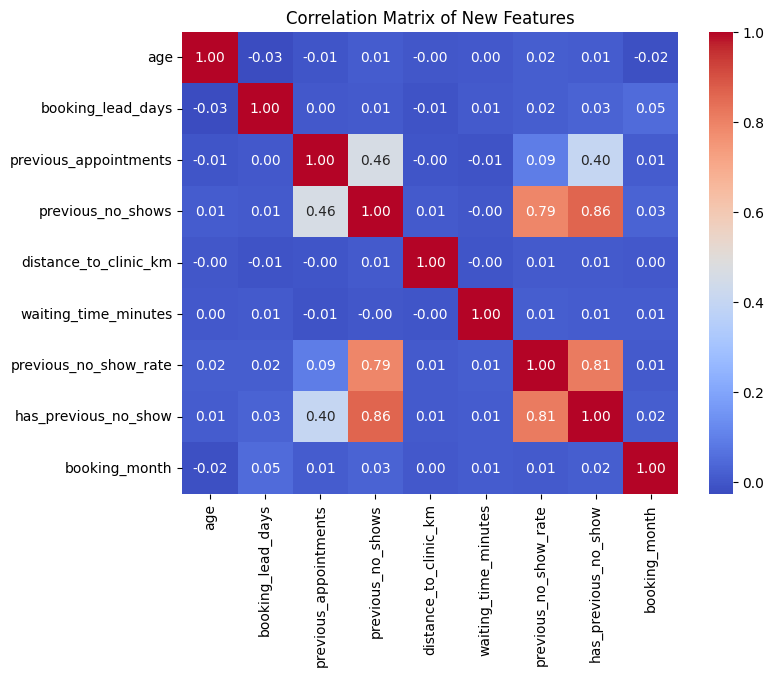

In [53]:
plt.figure(figsize=(8, 6))
sns.heatmap(df_model.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of New Features')

output_dir = 'figures'
os.makedirs(output_dir, exist_ok=True)
plt.savefig(os.path.join(output_dir, 'correlation_matrix_new_features.png')) # Save the figure
plt.show()

### Data Preparation and Grouped Train-Test Split

Now, let's prepare the data for modeling by dropping unnecessary or highly correlated features, and then perform a robust train-test split that ensures no patient overlap between the training and testing sets.

In [54]:
# Drop specified columns
drop_cols = ['has_previous_no_show', 'appointment_id', 'booking_date', 'appointment_date']
drop_cols.append('previous_no_shows')

# Ensure 'age_group' is dropped if it's still present and not needed for X
if 'age_group' in df_model.columns:
    drop_cols.append('age_group')

df_processed = df_model.drop(columns=drop_cols, errors='ignore')

# Separate patient_id for grouped splitting
patient_ids = df_processed['patient_id']

# Define features (X) and target (y)
X = df_processed.drop(columns=['patient_id', 'appointment_outcome'])
y = df_processed['appointment_outcome']

print("Shape of X before splitting:", X.shape)
print("Shape of y before splitting:", y.shape)

Shape of X before splitting: (4737, 13)
Shape of y before splitting: (4737,)


In [55]:
from sklearn.model_selection import GroupShuffleSplit

# Initialize GroupShuffleSplit
# test_size=0.2 means 20% for test set, random_state for reproducibility
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

# Get the single split (train_index, test_index)
for train_idx, test_idx in gss.split(X, y, groups=patient_ids):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    patient_ids_train, patient_ids_test = patient_ids.iloc[train_idx], patient_ids.iloc[test_idx]

print("Shapes after splitting:")
print(f"X_train: {X_train.shape}")
print(f"y_train: {y_train.shape}")
print(f"X_test: {X_test.shape}")
print(f"y_test: {y_test.shape}")

Shapes after splitting:
X_train: (3771, 13)
y_train: (3771,)
X_test: (966, 13)
y_test: (966,)


In [56]:
# Verify no patient overlap
common_patients = set(patient_ids_train).intersection(set(patient_ids_test))

if len(common_patients) == 0:
    print("SUCCESS: No patient overlap between training and testing sets.")
else:
    print(f"WARNING: {len(common_patients)} patients overlap between training and testing sets. Overlapping patient IDs: {list(common_patients)[:5]}...")


SUCCESS: No patient overlap between training and testing sets.


### Verify Target Variable Proportions

In [57]:
print("Proportions in y_train:")
display(y_train.value_counts(normalize=True).mul(100).round(2))

print("\nProportions in y_test:")
display(y_test.value_counts(normalize=True).mul(100).round(2))

Proportions in y_train:


,proportion
appointment_outcome,
No-Show,51.45
Attended,48.55



Proportions in y_test:


,proportion
appointment_outcome,
Attended,50.0
No-Show,50.0


### Feature Preprocessing: One-Hot Encoding and Standard Scaling

In [58]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

# Identify categorical and numerical columns in X_train
categorical_features = X_train.select_dtypes(include=['object']).columns
numerical_features = X_train.select_dtypes(include=['int64', 'float64']).columns

# Create a column transformer for preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# Fit and transform the training data
X_train_processed = preprocessor.fit_transform(X_train)

# Transform the test data
X_test_processed = preprocessor.transform(X_test)

print("Shape of processed X_train:", X_train_processed.shape)
print("Shape of processed X_test:", X_test_processed.shape)

Shape of processed X_train: (3771, 29)
Shape of processed X_test: (966, 29)


The `X_train_processed` and `X_test_processed` are now sparse matrices containing the scaled numerical features and one-hot encoded categorical features. The target variable `y_train` and `y_test` are still in their original 'Attended'/'No-Show' format. For modeling, these will likely need to be converted to numerical labels (e.g., 0 and 1).

### Convert Target Variable to Binary Labels

In [59]:
from sklearn.preprocessing import LabelEncoder

# Initialize LabelEncoder
le = LabelEncoder()

# Fit and transform y_train, then transform y_test
y_train_processed = le.fit_transform(y_train)
y_test_processed = le.transform(y_test)

# Display the mapping
print(f"Original labels: {le.classes_}")
print(f"Encoded labels: {le.transform(le.classes_)}")

print("\nFirst 5 elements of y_train_processed:")
display(y_train_processed[:5])

print("\nFirst 5 elements of y_test_processed:")
display(y_test_processed[:5])

Original labels: ['Attended' 'No-Show']
Encoded labels: [0 1]

First 5 elements of y_train_processed:


array([1, 0, 1, 0, 1])


First 5 elements of y_test_processed:


array([0, 0, 1, 0, 1])

In [60]:
X_train_processed

array([[-0.53893785, -1.0117561 , -0.58947828, ...,  0.        ,
         0.        ,  1.        ],
       [-0.97925408, -1.58569741,  1.68752309, ...,  0.        ,
         1.        ,  0.        ],
       [ 0.06649698,  0.48049131,  1.11827275, ...,  0.        ,
         1.        ,  0.        ],
       ...,
       [ 0.78201086,  1.62837393, -0.58947828, ...,  0.        ,
         0.        ,  1.        ],
       [ 0.01145745, -0.09345   ,  1.11827275, ...,  0.        ,
         0.        ,  0.        ],
       [ 0.17657603,  1.74316219,  1.68752309, ...,  0.        ,
         0.        ,  1.        ]])

### Train a Baseline Logistic Regression Model

In [61]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

# Initialize and train the Logistic Regression model
# Set max_iter for convergence with StandardScaler
log_reg_model = LogisticRegression(random_state=42, max_iter=1000)
log_reg_model.fit(X_train_processed, y_train_processed)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


### Evaluate the Model on Testing Data

Classification Report:
              precision    recall  f1-score   support

    Attended       0.64      0.60      0.62       483
     No-Show       0.62      0.66      0.64       483

    accuracy                           0.63       966
   macro avg       0.63      0.63      0.63       966
weighted avg       0.63      0.63      0.63       966

Confusion Matrix:


array([[292, 191],
       [166, 317]])

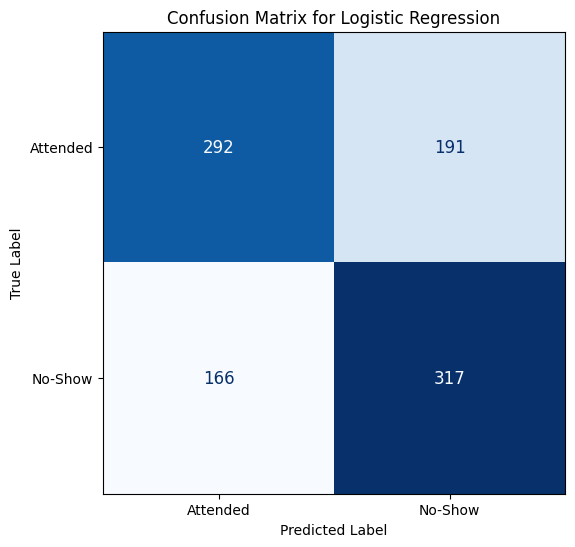

In [62]:
# Make predictions on the processed test data
y_pred = log_reg_model.predict(X_test_processed)

# Display classification report
print("Classification Report:")
print(classification_report(y_test_processed, y_pred, target_names=['Attended', 'No-Show']))

# Display confusion matrix
cm = confusion_matrix(y_test_processed, y_pred)
print("Confusion Matrix:")
display(cm)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(y_test_processed, y_pred, cmap='Blues',
                                          colorbar=False, ax=plt.gca(), values_format='d',
                                          xticks_rotation='horizontal', normalize=None,
                                          text_kw={"fontsize":12},
                                          display_labels=le.classes_)
plt.title('Confusion Matrix for Logistic Regression')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.grid(False)

output_dir = 'figures'
os.makedirs(output_dir, exist_ok=True)
plt.savefig(os.path.join(output_dir, 'confusion_matrix.png')) # Save the figure
plt.show()

### ROC-AUC Curve Evaluation

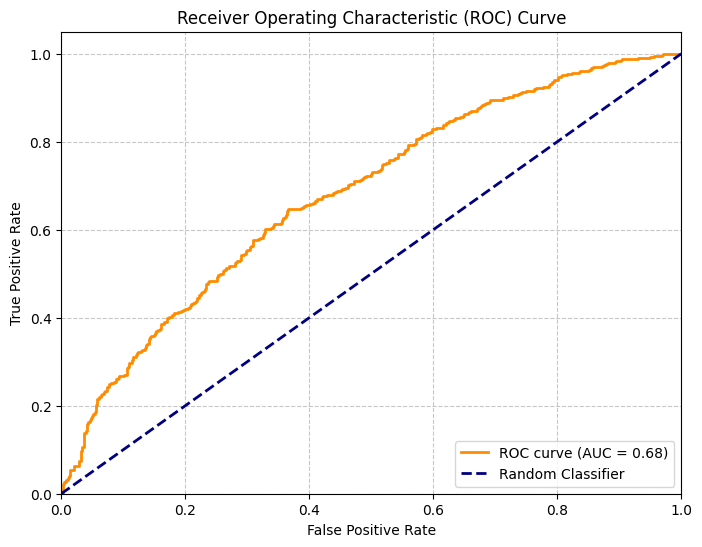

AUC Score: 0.68


In [63]:
from sklearn.metrics import roc_curve, auc

# Get predicted probabilities for the positive class (No-Show, which is label 1)
y_pred_proba = log_reg_model.predict_proba(X_test_processed)[:, 1]

# Compute ROC curve and AUC score
fpr, tpr, thresholds = roc_curve(y_test_processed, y_pred_proba)
roc_auc = auc(fpr, tpr)

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.7)

output_dir = 'figures'
os.makedirs(output_dir, exist_ok=True)
plt.savefig(os.path.join(output_dir, 'roc_curve.png')) # Save the figure
plt.show()

print(f"AUC Score: {roc_auc:.2f}")

In [65]:
df_processed.head()

,patient_id,gender,age,appointment_type,appointment_day,appointment_time,booking_lead_days,previous_appointments,reminder_sent,reminder_channel,distance_to_clinic_km,waiting_time_minutes,appointment_outcome,previous_no_show_rate,booking_month
0,P-1613,Female,39,Follow-up,Tuesday,Afternoon,12,2,Yes,WhatsApp,19.3,29.0,No-Show,0.000000,2
1,P-0813,Male,31,Specialist Consultation,Friday,Morning,2,6,Yes,SMS,14.3,42.0,Attended,0.000000,2
2,P-1366,Female,50,General Consultation,Wednesday,Morning,38,5,Yes,SMS,11.4,11.0,No-Show,0.200000,11
3,P-1031,Male,59,Follow-up,Thursday,Evening,41,3,Yes,SMS,7.4,35.0,Attended,0.333333,7
4,P-1458,Female,34,Follow-up,Monday,Afternoon,47,3,Yes,Email,5.6,27.0,No-Show,0.333333,7


In [66]:
df_model.head()

,appointment_id,patient_id,gender,age,age_group,appointment_type,booking_date,appointment_date,appointment_day,appointment_time,...,previous_appointments,previous_no_shows,reminder_sent,reminder_channel,distance_to_clinic_km,waiting_time_minutes,appointment_outcome,previous_no_show_rate,has_previous_no_show,booking_month
0,HC-00001,P-1613,Female,39,35-44,Follow-up,2025-02-06,2/18/2025,Tuesday,Afternoon,...,2,0,Yes,WhatsApp,19.3,29.0,No-Show,0.000000,0,2
1,HC-00002,P-0813,Male,31,25-34,Specialist Consultation,2026-02-25,2/27/2026,Friday,Morning,...,6,0,Yes,SMS,14.3,42.0,Attended,0.000000,0,2
2,HC-00003,P-1366,Female,50,45-54,General Consultation,2025-11-16,12/24/2025,Wednesday,Morning,...,5,1,Yes,SMS,11.4,11.0,No-Show,0.200000,1,11
3,HC-00004,P-1031,Male,59,55-64,Follow-up,2025-07-18,8/28/2025,Thursday,Evening,...,3,1,Yes,SMS,7.4,35.0,Attended,0.333333,1,7
4,HC-00005,P-1458,Female,34,25-34,Follow-up,2025-07-09,8/25/2025,Monday,Afternoon,...,3,1,Yes,Email,5.6,27.0,No-Show,0.333333,1,7


### Combine Processed Data into a Single CSV

In [69]:
# Use the already encoded y_train_processed and y_test_processed

# Get feature names from the preprocessor
feature_names = preprocessor.get_feature_names_out()

# Convert processed X_train and X_test to DataFrames with feature names
X_train_df = pd.DataFrame(X_train_processed, columns=feature_names)
X_test_df = pd.DataFrame(X_test_processed, columns=feature_names)

# Convert processed y_train and y_test to DataFrames, using a new name for the encoded target
y_train_df = pd.DataFrame(y_train_processed, columns=['appointment_outcome_encoded'])
y_test_df = pd.DataFrame(y_test_processed, columns=['appointment_outcome_encoded'])

# Combine training and testing features and target
X_combined = pd.concat([X_train_df, X_test_df], ignore_index=True)
y_combined = pd.concat([y_train_df, y_test_df], ignore_index=True)

# Create the final processed DataFrame
df_processed_final = pd.concat([X_combined, y_combined], axis=1)

# Display the first few rows and shape of the combined DataFrame
print("Shape of the final processed DataFrame:", df_processed_final.shape)
display(df_processed_final.head())

# Save the combined DataFrame to a CSV file
output_filename = 'healthconnect_proccessed_data.csv'
df_processed_final.to_csv(output_filename, index=False)
print(f"Processed data saved to {output_filename}")

Shape of the final processed DataFrame: (4737, 30)


,num__age,num__booking_lead_days,num__previous_appointments,num__distance_to_clinic_km,num__waiting_time_minutes,num__previous_no_show_rate,cat__gender_Female,cat__gender_Male,cat__gender_Prefer not to say,cat__appointment_type_Diagnostic Test,...,cat__appointment_time_Afternoon,cat__appointment_time_Evening,cat__appointment_time_Morning,cat__reminder_sent_No,cat__reminder_sent_Yes,cat__reminder_channel_Email,cat__reminder_channel_No_Reminder_Channel,cat__reminder_channel_SMS,cat__reminder_channel_WhatsApp,appointment_outcome_encoded
0,-0.538938,-1.011756,-0.589478,1.432998,0.432352,-0.701018,1.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1
1,-0.979254,-1.585697,1.687523,0.660531,1.641571,-0.701018,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0
2,0.066497,0.480491,1.118273,0.212501,-1.241952,0.119923,1.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1
3,0.561853,0.652674,-0.020228,-0.405472,0.990453,0.667217,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0
4,-0.814135,0.997038,-0.020228,-0.683560,0.246318,0.667217,1.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1


Processed data saved to healthconnect_proccessed_data.csv
